# Synthetic Control Method

# Data

In [1]:
import pandas as pd
from causalis.scenarios.synthetic_control.dgp import generate_scm_gamma_26

df = generate_scm_gamma_26(treatment_effect_rate=1.0, return_panel_data=False, include_oracles=True)

# Treated post-period rows are exactly treated_time == 1
post_treated = df[df["treated_time"] == 1].copy()
atte_true = post_treated["tau_realized_true"].mean()

print(f"Ground-truth ATTE is {atte_true:.6f}")

Ground-truth ATTE is 23.620687


In [2]:
df.head()

,unit_id,calendar_time,treated_time,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true
0,donor_1,2000-01,0,3.467349,3.467349,0.0,8.613315,8.613315,0.0
1,donor_1,2000-02,0,5.583724,5.583724,0.0,8.311302,8.311302,0.0
2,donor_1,2000-03,0,9.547764,9.547764,0.0,12.425266,12.425266,0.0
3,donor_1,2000-04,0,11.787204,11.787204,0.0,13.319691,13.319691,0.0
4,donor_1,2000-05,0,11.379233,11.379233,0.0,11.194818,11.194818,0.0


In [3]:
from causalis.data_contracts import PanelDataSCM

paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_time='treated_time'
)

# EDA

In [4]:
paneldata

PanelDataSCM(df=(1333, 4), y='y', unit_col='unit_id', time_col='calendar_time', treated_time='treated_time', time_freq='M', treated_unit='treated', treatment_start=Period('2003-02', 'M'), last_post_period=Period('2003-07', 'M'), n_pre_periods=37, n_post_periods=6, donor_units=['donor_1', 'donor_10', 'donor_11', 'donor_12', 'donor_13', 'donor_14', 'donor_15', 'donor_16', 'donor_17', 'donor_18', 'donor_19', 'donor_2', 'donor_20', 'donor_21', 'donor_22', 'donor_23', 'donor_24', 'donor_25', 'donor_26', 'donor_27', 'donor_28', 'donor_29', 'donor_3', 'donor_30', 'donor_4', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9'])

In [5]:
from causalis.scenarios.synthetic_control.refutation import donors_diagnostics

In [6]:
donors_diagnostics(paneldata)

,donor,pre_mean,pre_std,pre_slope,corr_with_treated_pre,rmse_to_treated_pre,rmse_to_treated_pre_standardized,mean_diff_pre,slope_diff_pre,max_abs_gap_pre,is_never_treated,n_missing_pre,corr_rank,std_rmse_rank,slope_rank,composite_similarity_score,rank_by_similarity,notes
0,donor_30,24.301740,11.386682,0.197944,0.578329,9.811038,1.021953,0.935398,-0.055807,24.507654,True,0,1,1,5,0.955556,1,high_std_rmse
1,donor_23,18.869610,7.601863,0.253214,0.268212,11.446663,1.192325,-4.496731,-0.000537,36.414014,True,0,11,4,1,0.855556,2,high_std_rmse
2,donor_24,12.492136,5.682518,0.205733,0.531084,13.592627,1.415856,-10.874206,-0.048018,38.943747,True,0,2,11,3,0.855556,3,high_std_rmse
3,donor_3,21.414308,9.650929,0.244165,0.308308,11.488508,1.196684,-1.952033,-0.009586,28.135333,True,0,9,5,2,0.855556,4,high_std_rmse
4,donor_26,16.258293,7.331208,0.096444,0.498547,11.236518,1.170436,-7.108048,-0.157307,28.181638,True,0,3,3,13,0.822222,5,high_std_rmse
5,donor_21,19.993713,8.288429,0.100738,0.327993,10.956301,1.141247,-3.372628,-0.153013,26.484825,True,0,8,2,12,0.788889,6,high_std_rmse
6,donor_9,20.922253,10.238605,0.144813,0.305516,11.954394,1.245212,-2.444088,-0.108939,29.760025,True,0,10,7,9,0.744444,7,high_std_rmse
7,donor_10,20.536252,14.540358,0.113550,0.394726,14.191406,1.478227,-2.830089,-0.140201,36.087127,True,0,5,13,10,0.722222,8,high_std_rmse
8,donor_18,15.049971,7.682466,0.202496,0.184261,13.898486,1.447716,-8.316371,-0.051255,53.539919,True,0,17,12,4,0.666667,9,high_std_rmse
9,donor_6,11.279497,4.982679,-0.016152,0.491095,14.700381,1.531244,-12.086844,-0.269904,43.193997,True,0,4,14,18,0.633333,10,high_std_rmse


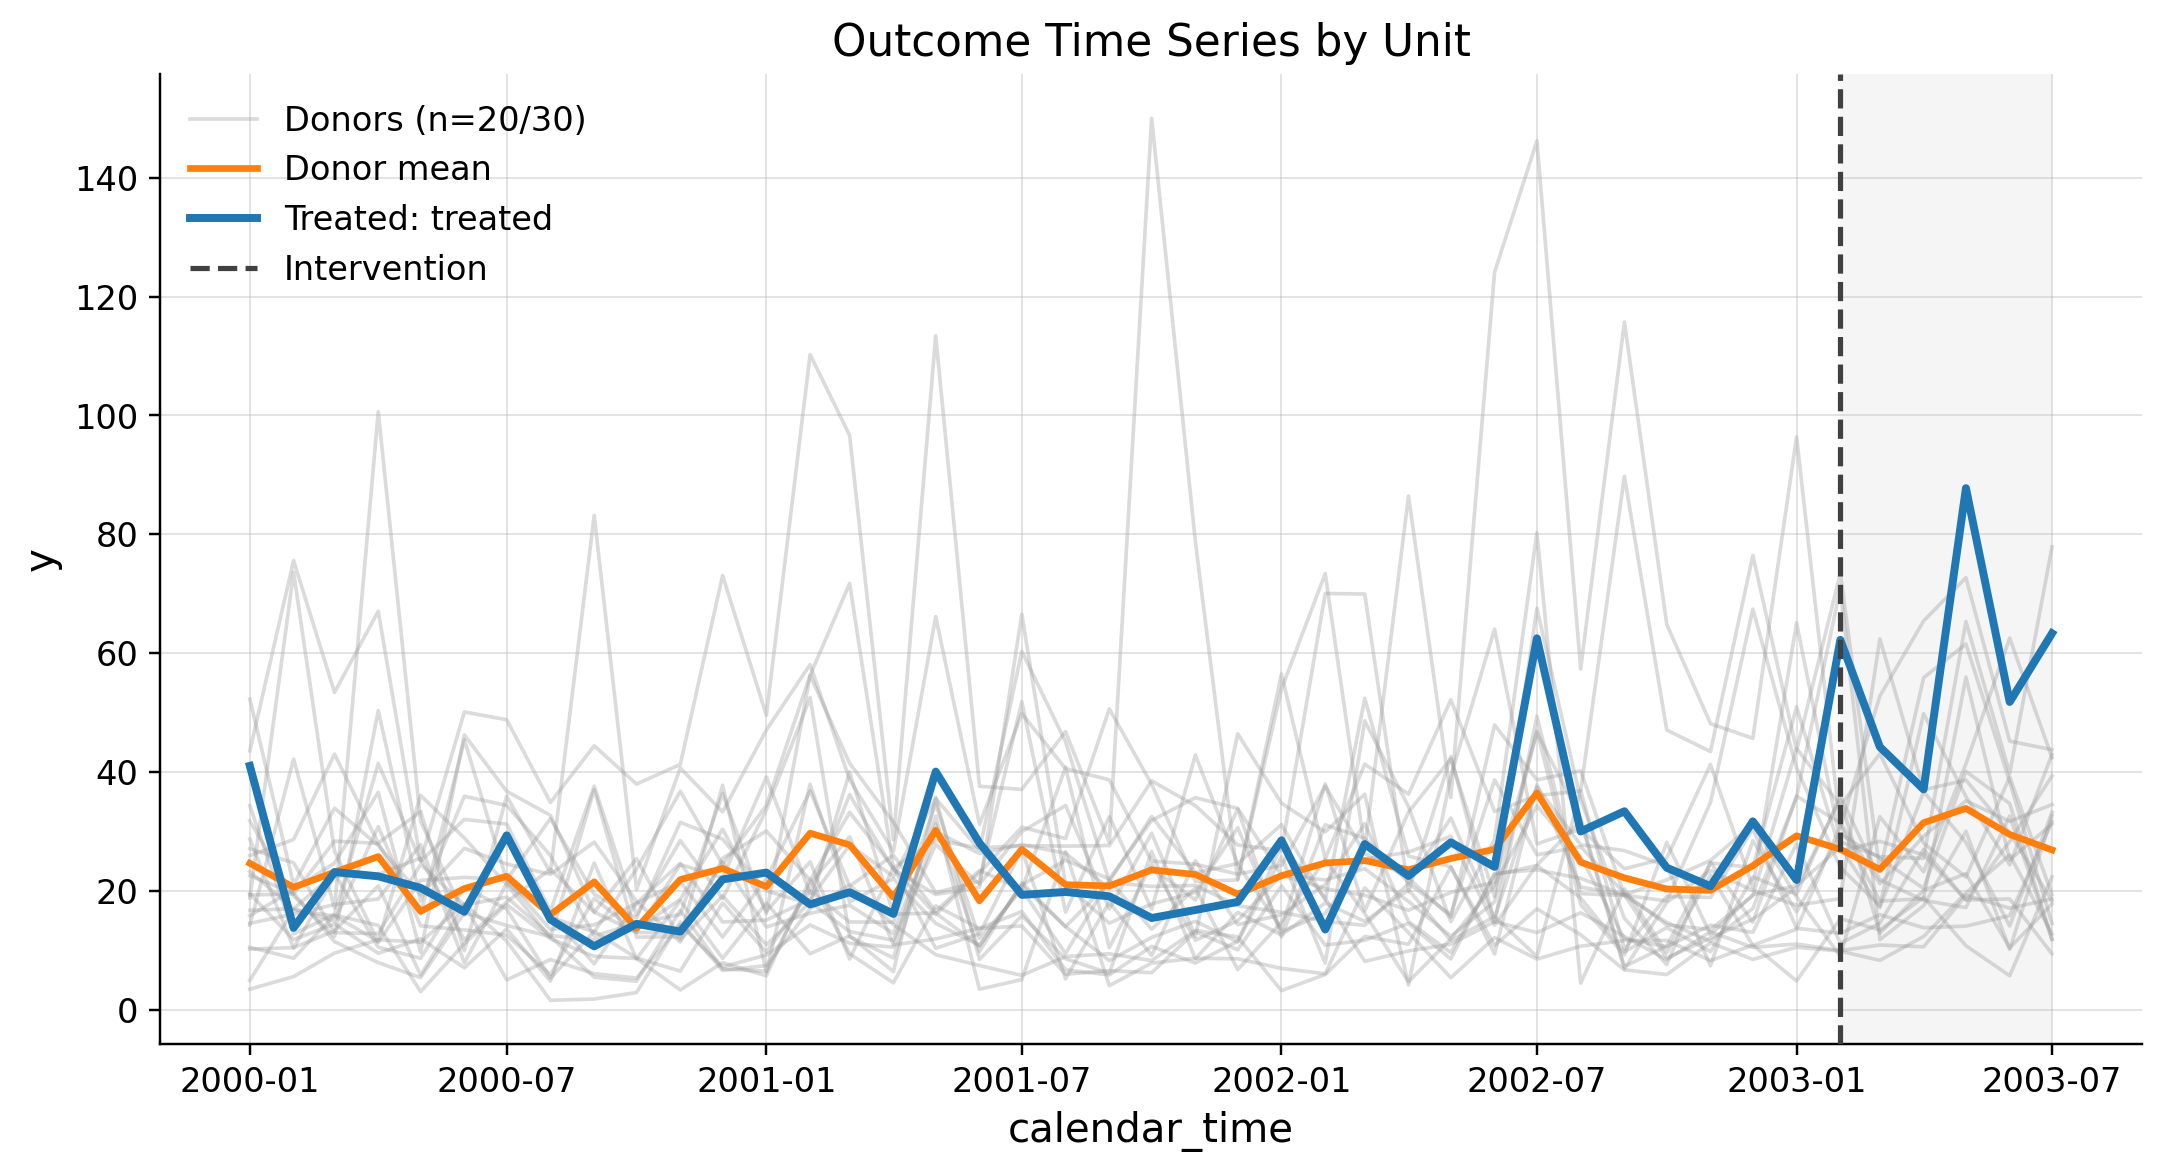

In [7]:
from causalis.scenarios.synthetic_control.refutation import outcome_panel_plot

outcome_panel_plot(paneldata)

# Inference

In [8]:
from causalis.scenarios.synthetic_control import AugmentedSyntheticControl
model = AugmentedSyntheticControl(
    lambda_aug=5,
    conformal_grid_scale_mult=12,
    conformal_grid_size=101

).fit(paneldata)
result = model.estimate()

/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(


In [9]:
result.summary()

,value
field,
estimand,average_post_effect
model,AugmentedSyntheticControl
inference,average_att_ttest
value,"25.8194 (ci_abs: 4.7885, 46.8503)"
value_relative,"94.3285 (ci_rel: 17.4942, 171.1628)"
alpha,0.0500
p_value,0.0340
is_significant,True
post_outcome_d_mean,57.7404


# Refutation

In [11]:
from causalis.scenarios.synthetic_control.refutation import (run_placebo_tests,
                                                             leave_one_donor_out_sensitivity)

In [12]:
run_placebo_tests(result, paneldata, model_kwargs={
    "conformal_grid_size":31,
    "average_att_n_folds": 2
},
                  )

/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights ar

{'placebo_in_space':      unit_id   pre_rmse   post_rmse  post_pre_rmspe_ratio  average_post_gap  \
 0    donor_6   1.370651   20.771440             15.154436        -11.520749   
 1    donor_3   3.116095   45.172013             14.496352         23.455966   
 2   donor_25   3.153032   45.044702             14.286154        -20.072214   
 3   donor_12   2.540937   35.512128             13.975996         18.472057   
 4   donor_15   3.788607   48.197816             12.721777         28.874761   
 5    donor_2   6.025026   70.762397             11.744746        -46.031539   
 6    treated   2.900920   33.461007             11.534617         30.368575   
 7   donor_20   2.791034   31.791199             11.390472         17.537140   
 8   donor_14   5.046626   56.264776             11.148988        -13.133676   
 9   donor_22   5.222420   56.459742             10.811030         44.478512   
 10  donor_23   2.640848   26.595323             10.070753         17.550504   
 11  donor_17   6.15

In [13]:
leave_one_donor_out_sensitivity(result, paneldata)

/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights are extreme; estimates may be unstable.
  self._warn_on_augmented_weight_metrics(
/Users/ioannmartynov/PycharmProjects/Ckit/causalis/scenarios/synthetic_control/model.py:1591: RuntimeWarning: Augmented donor weights ar

,dropped_donor,average_att_reestimated,delta_vs_full_model,pre_rmse_reestimated,max_weight_after_refit,effective_n_donors_after_refit
0,donor_1,27.395922,1.576517,2.901932,1.006262,0.232970
1,donor_10,22.879382,-2.940023,3.001851,0.971276,0.234458
2,donor_11,26.538778,0.719373,2.942467,1.070943,0.220556
3,donor_12,22.910452,-2.908953,3.196627,0.752118,0.332862
4,donor_13,29.145860,3.326455,2.935869,1.023585,0.246142
5,donor_14,29.322249,3.502844,2.903866,1.018136,0.239665
6,donor_15,21.537563,-4.281842,3.331201,0.649737,0.351982
7,donor_16,22.313159,-3.506246,2.961757,0.845211,0.254651
8,donor_17,24.329390,-1.490015,2.898803,0.936818,0.249367
9,donor_18,32.124069,6.304664,3.209808,1.064367,0.252581


In [14]:
from causalis.scenarios.synthetic_control.refutation import run_scm_diagnostics

run_scm_diagnostics(result, paneldata)

{'metrics': {'n_donors': 30,
  'n_pre': 37,
  'n_post': 6,
  'pre_rmse_sc': None,
  'pre_rmse_aug': 2.9009204215039173,
  'pre_rmse_augmented': 2.9009204215039173,
  'pre_mae_augmented': 2.234709492260269,
  'max_abs_pre_gap': 6.223884867840921,
  'mean_signed_pre_gap': -0.0071900612373224015,
  'att_sc': None,
  'att_aug': 25.819405057785108,
  'max_weight_sc': 0.33826989392118606,
  'max_abs_weight_aug': 0.8932418075053803,
  'max_abs_weight_augmented': 0.8932418075053803,
  'l1_norm_weight_aug': 8.47556428155435,
  'l1_norm_weights_augmented': 8.47556428155435,
  'sum_weights_augmented': 0.9999999999999998,
  'effective_n_donors': 0.26359759915375425,
  'herfindahl_weights': 3.7936612594741748,
  'negative_weight_share': 0.4410068777263401,
  'n_negative_weights': 13,
  'cond_augmented_gram': 17468.064295701315,
  'n_placebos': 3,
  'min_possible_p': 0.25,
  'p_value_att': 0.03402035361575935,
  'ci_low_abs': 4.7884752972672295,
  'ci_high_abs': 46.85033481830298,
  'placebo_ci_is_u

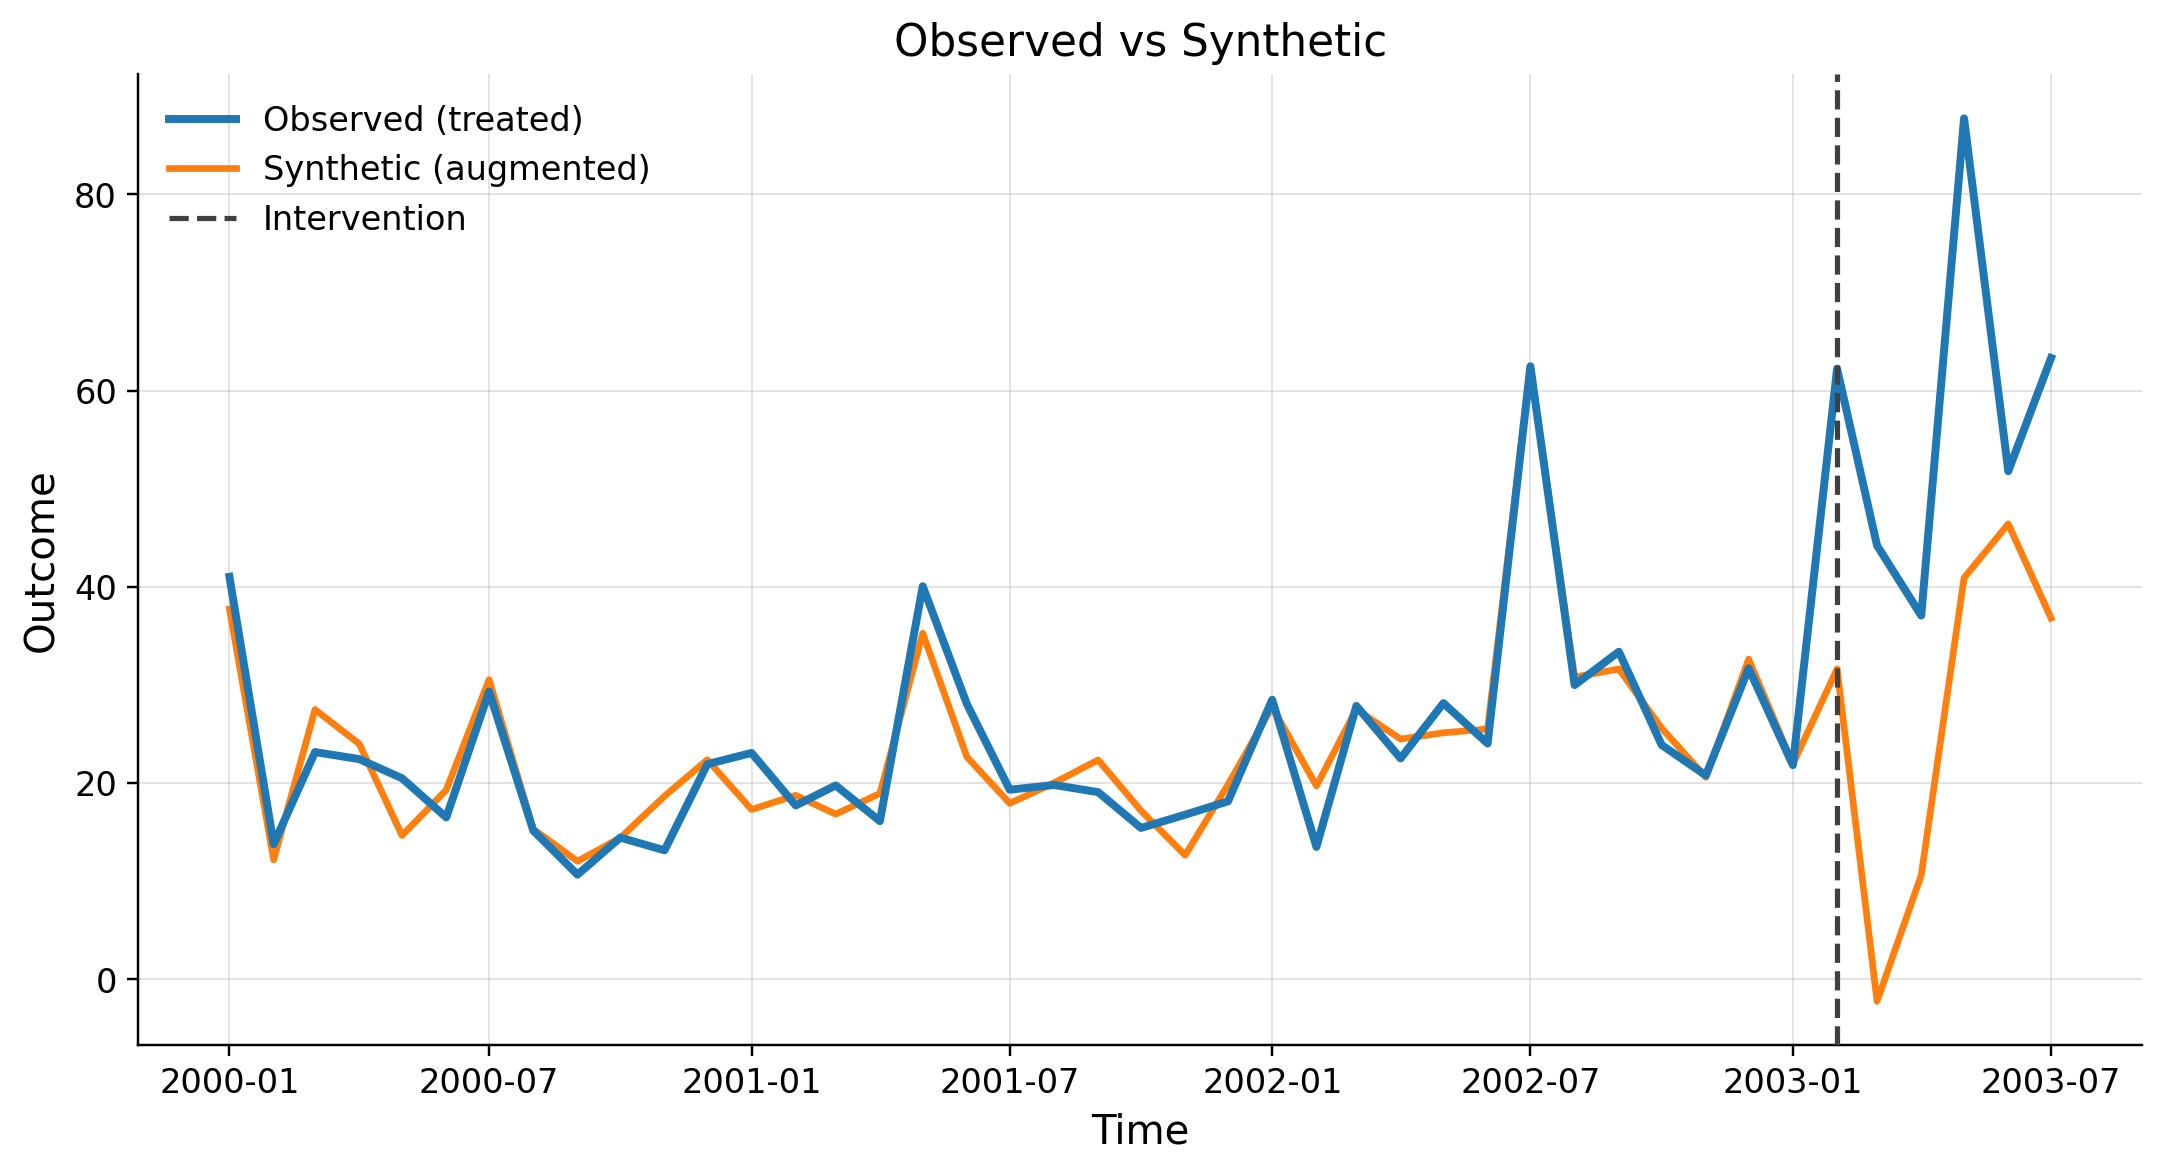

In [15]:
from causalis.scenarios.synthetic_control.refutation import observed_vs_synthetic_plot
observed_vs_synthetic_plot(result)

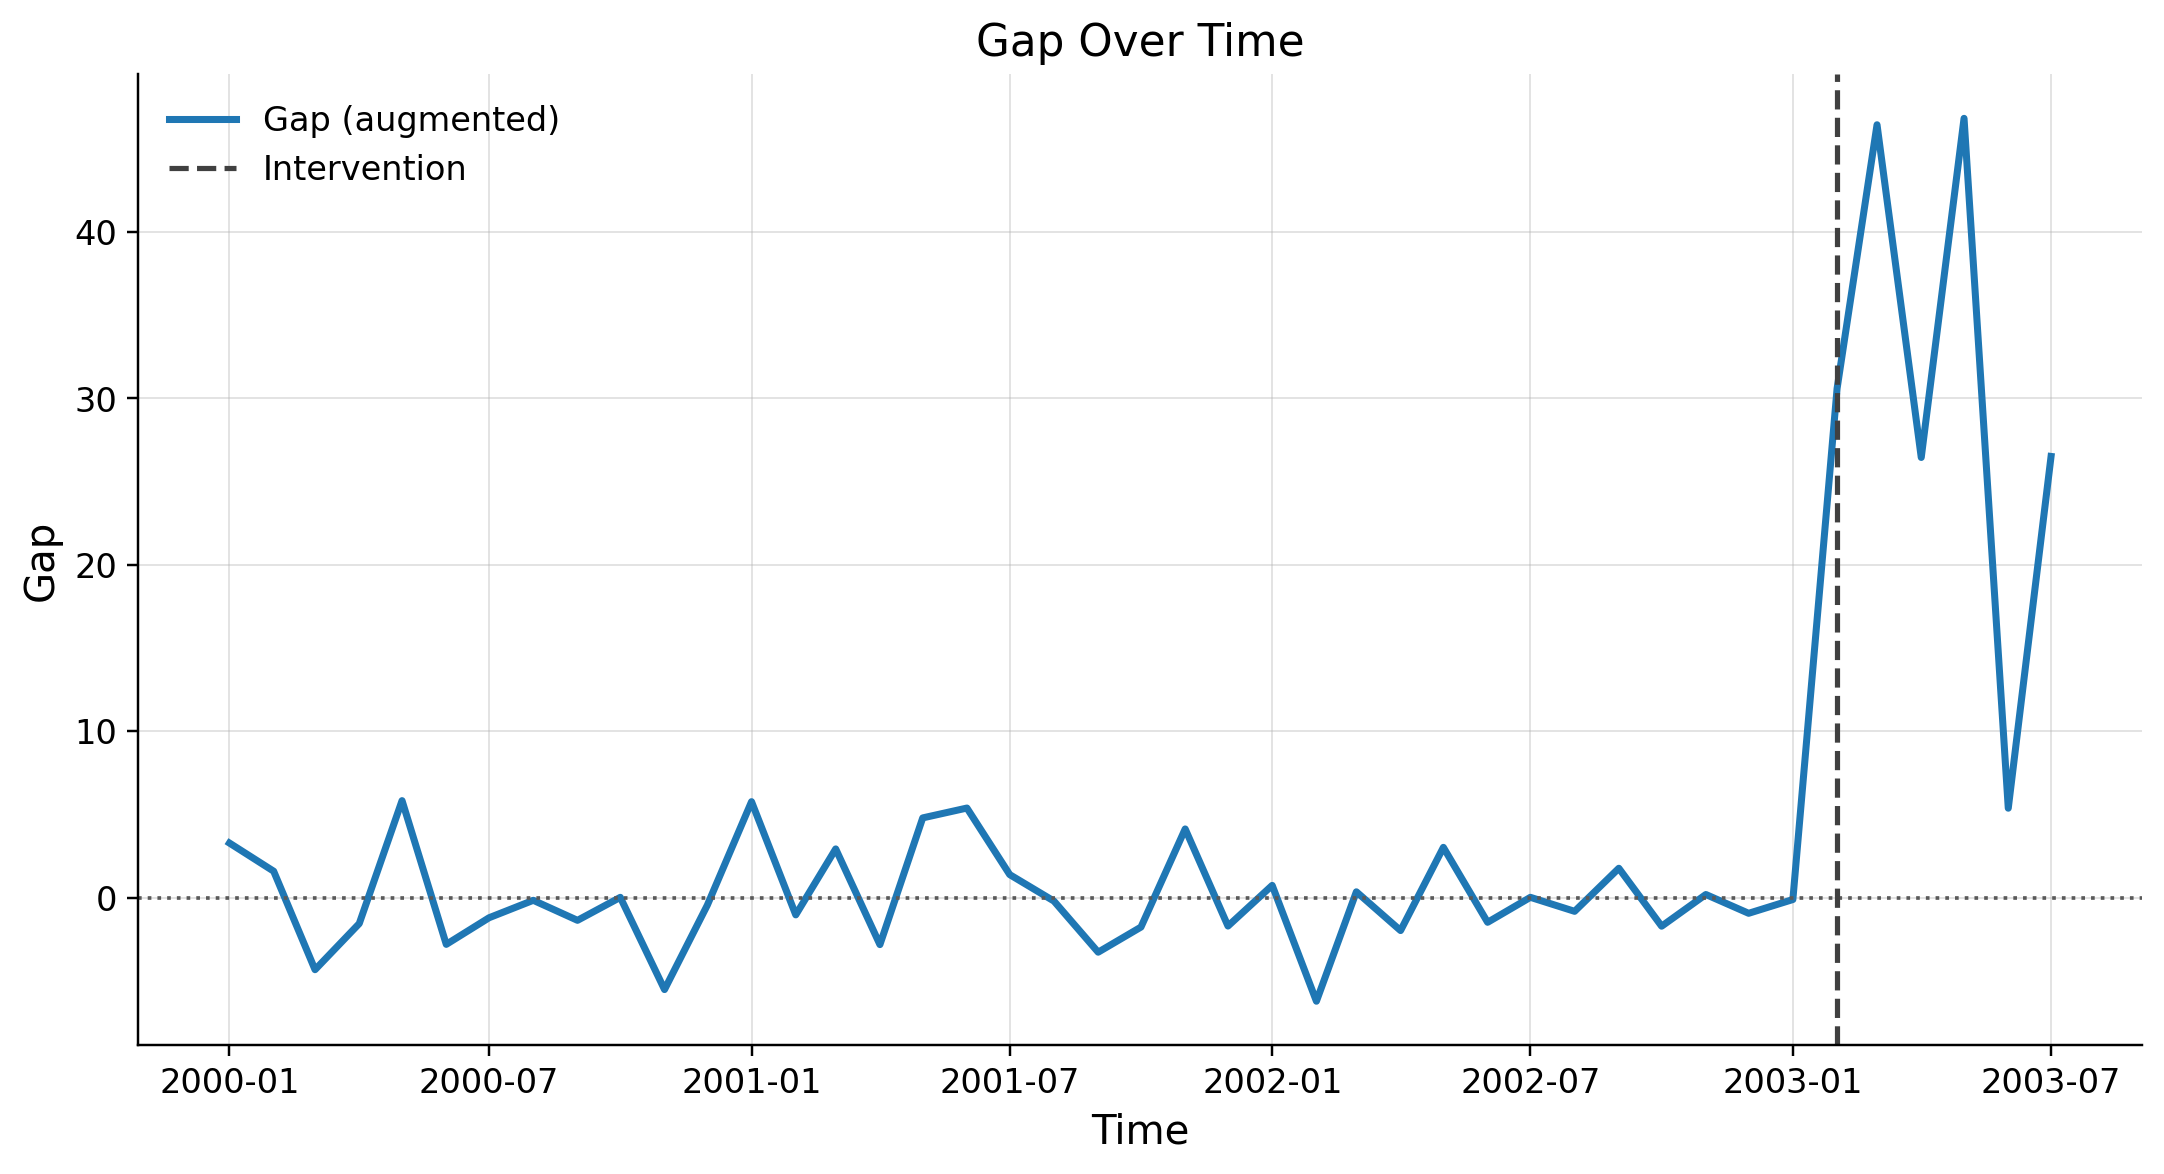

In [16]:
from causalis.scenarios.synthetic_control.refutation import gap_over_time_plot
gap_over_time_plot(result)


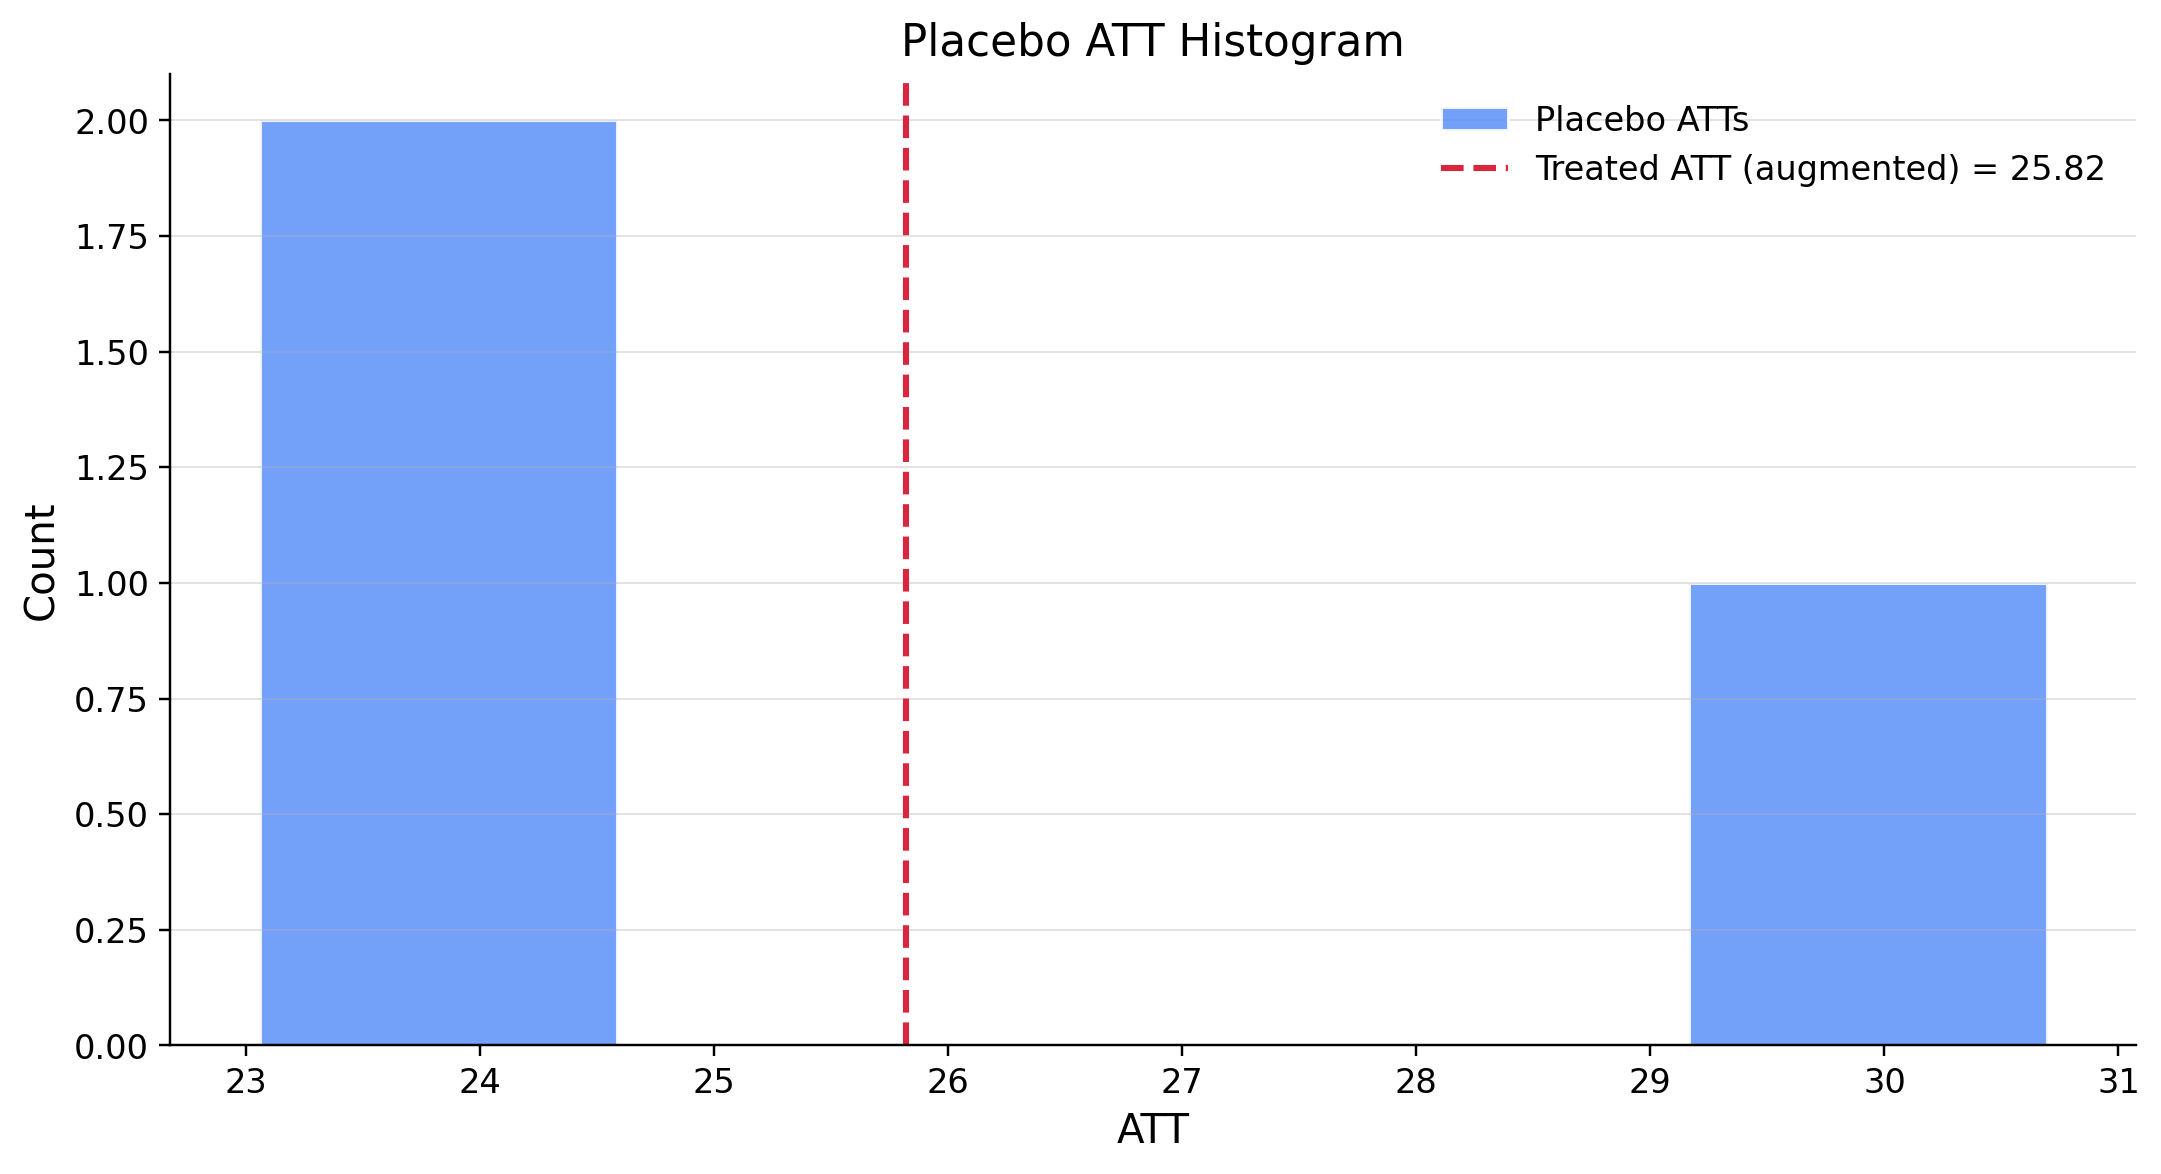

In [17]:
from causalis.scenarios.synthetic_control.refutation import placebo_att_histogram_plot
placebo_att_histogram_plot(result)

In [18]:
d = result.diagnostics
print("ATT available:", d["average_att_ttest_available"])
print("ATT estimate:", d["average_att_estimate"])
print("ATT CI:", d["average_att_ci_lower"], d["average_att_ci_upper"])
print("ATT p-value:", d["average_att_p_value"])
print("Folds used:", d["average_att_n_folds_used"])
print("Fold estimates:", d["average_att_fold_estimates"])

ATT available: True
ATT estimate: 25.819405057785108
ATT CI: 4.7884752972672295 46.85033481830298
ATT p-value: 0.03402035361575935
Folds used: 3
Fold estimates: {'fold_1': 30.693016736210765, 'fold_2': 23.706011661643842, 'fold_3': 23.05918677550072}
